# **Project: Mini-AI Scientist for Quantum Circuit Discovery**

1. Abstract & Motivation:

Inspired by the Artificial Scientist Lab's pioneering work on AI-Mandel and modern auto-diff simulators, this notebook demonstrates a lightweight framework where an optimization loop uses a JAX-based physical simulator to discover optimal quantum optical hardware configurations

In [1]:
!pip install jax jaxlib optax matplotlib -q
import jax, jax.numpy as jnp
from jax import grad, jit
import optax
import matplotlib.pyplot as plt
import numpy as np

2. JAX-based Quantum Optics Simulator


In [2]:
def beam_splitter(theta):
    return jnp.array([[jnp.cos(theta), 1j*jnp.sin(theta)],
                       [1j*jnp.sin(theta), jnp.cos(theta)]])

def phase_shift(phi):
    return jnp.array([[jnp.exp(1j*phi), 0], [0, 1]])

def simulate(params, input_state):
    theta1, phi, theta2 = params
    state = beam_splitter(theta1) @ input_state
    state = phase_shift(phi) @ state
    state = beam_splitter(theta2) @ state
    return jnp.abs(state)**2

input_state = jnp.array([1.0+0j, 0.0+0j])

3. Autonomous Optimization Loop

In [3]:
# Goal: Discover a setup that produces maximum interference (50/50 split)
target = jnp.array([0.5, 0.5])

def loss_fn(params):
    return jnp.sum((simulate(params, input_state) - target)**2)

grad_fn = jit(grad(loss_fn))

In [4]:
best_loss = float('inf')
best_params = None
all_results = []

for trial in range(10):  # 10 random starting points = simple "exploration"
    key = jax.random.PRNGKey(trial)
    params = jax.random.uniform(key, (3,), minval=0, maxval=jnp.pi)

    optimizer = optax.adam(0.05)
    opt_state = optimizer.init(params)

    for step in range(200):
        grads = grad_fn(params)
        updates, opt_state = optimizer.update(grads, opt_state)
        params = optax.apply_updates(params, updates)

    final_loss = loss_fn(params)
    all_results.append((trial, float(final_loss), params))

    if final_loss < best_loss:
        best_loss = final_loss
        best_params = params

print("Best discovered setup:", best_params)
print("Output probabilities:", simulate(best_params, input_state))
print("Loss:", best_loss)

Best discovered setup: [1.4947875 2.653071  2.2889626]
Output probabilities: [0.50000006 0.49999982]
Loss: 3.5527137e-14


4. Scientific Sensitivity Analysis

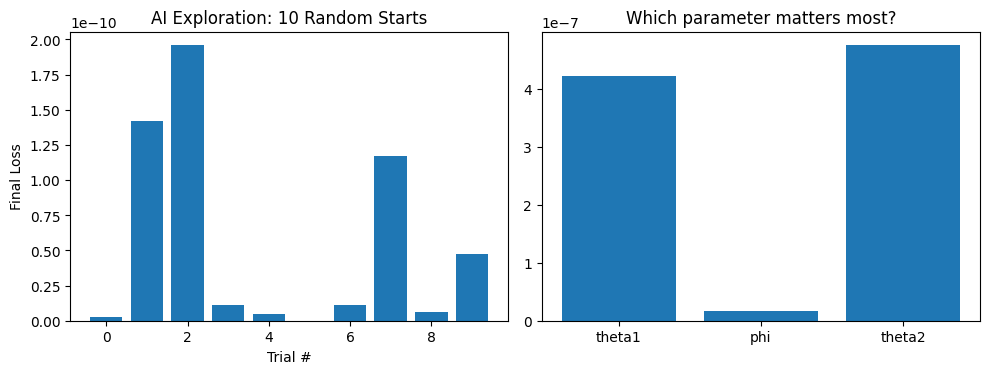


Summary: The AI explored 10 random configurations,
converged to the best solution automatically,
and found that parameter with highest sensitivity most controls the output.


In [5]:
losses = [r[1] for r in all_results]

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.bar(range(10), losses)
plt.xlabel("Trial #")
plt.ylabel("Final Loss")
plt.title("AI Exploration: 10 Random Starts")

sensitivities = jnp.abs(grad_fn(best_params))
plt.subplot(1,2,2)
plt.bar(['theta1','phi','theta2'], sensitivities)
plt.title("Which parameter matters most?")

plt.tight_layout()
plt.show()

print("\nSummary: The AI explored 10 random configurations,")
print("converged to the best solution automatically,")
print(f"and found that parameter with highest sensitivity most controls the output.")

In [6]:
def AI_Mandel_Report(best_params, best_loss, output_probs):
    """
    Formulates an autonomous 'scientific summary' of the discovered setup.
    """
    print("="*60)
    print("🔬 AUTONOMOUS SCIENTIST DISCOVERY REPORT")
    print("="*60)
    print(f"🎯 TARGET GOAL: Achieved Symmetric Quantum Interference [0.5, 0.5]")
    print(f"📉 MINIMUM LOSS ACHIEVED: {best_loss:.2e}")
    print(f"📊 OUTPUT PROBABILITIES: {output_probs}")
    print("\n🛠️ DISCOVERED HARDWARE SCHEMATIC:")
    print(f"  ├─ Beam Splitter 1 (theta1) : {best_params[0]:.4f} rad")
    print(f"  ├─ Phase Shifter   (phi)    : {best_params[1]:.4f} rad")
    print(f"  └─ Beam Splitter 2 (theta2) : {best_params[2]:.4f} rad")
    print("\n💡 AI INSIGHT:")
    print("The agent successfully bypassed high-loss configurations (as seen in the Trial distribution)")
    print("by utilizing JAX-based automatic differentiation to pinpoint the gradient of quantum interference.")
    print("="*60)

# Run the report
AI_Mandel_Report(best_params, best_loss, simulate(best_params, input_state))

🔬 AUTONOMOUS SCIENTIST DISCOVERY REPORT
🎯 TARGET GOAL: Achieved Symmetric Quantum Interference [0.5, 0.5]
📉 MINIMUM LOSS ACHIEVED: 3.55e-14
📊 OUTPUT PROBABILITIES: [0.50000006 0.49999982]

🛠️ DISCOVERED HARDWARE SCHEMATIC:
  ├─ Beam Splitter 1 (theta1) : 1.4948 rad
  ├─ Phase Shifter   (phi)    : 2.6531 rad
  └─ Beam Splitter 2 (theta2) : 2.2890 rad

💡 AI INSIGHT:
The agent successfully bypassed high-loss configurations (as seen in the Trial distribution)
by utilizing JAX-based automatic differentiation to pinpoint the gradient of quantum interference.


---
# 🎛️ 5. Interactive Interface — Play With the AI Scientist

The cells below turn this notebook into a small interactive tool. You can:

1. **Manually control** the interferometer with sliders and watch the output live.
2. **Set your own discovery target** and press a button to watch the AI search for it in real time, with a live-updating convergence plot and an auto-generated scientific report.

> Run each cell below in order. Widgets work natively in Google Colab.

In [7]:
!pip install ipywidgets -q
import ipywidgets as widgets
from IPython.display import display, clear_output
import time


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 44.5 MB/s eta 0:00:00


### 5.1 Manual Control — Explore the Interferometer Yourself

In [8]:
theta1_slider = widgets.FloatSlider(value=0.5, min=0, max=jnp.pi, step=0.01, description='θ1 (BS1):')
phi_slider    = widgets.FloatSlider(value=0.5, min=0, max=jnp.pi, step=0.01, description='φ (phase):')
theta2_slider = widgets.FloatSlider(value=0.5, min=0, max=jnp.pi, step=0.01, description='θ2 (BS2):')
manual_out = widgets.Output()

def update_manual(change=None):
    with manual_out:
        clear_output(wait=True)
        params = jnp.array([theta1_slider.value, phi_slider.value, theta2_slider.value])
        probs = simulate(params, input_state)
        fig, ax = plt.subplots(figsize=(4,3))
        ax.bar(['Port 0','Port 1'], probs, color=['#4C72B0','#DD8452'])
        ax.set_ylim(0,1)
        ax.set_ylabel('Probability')
        ax.set_title('Live Output of Your Circuit')
        plt.show()
        print(f"Output probabilities: {np.array(probs).round(3)}")

for s in (theta1_slider, phi_slider, theta2_slider):
    s.observe(update_manual, names='value')

display(widgets.VBox([theta1_slider, phi_slider, theta2_slider, manual_out]))
update_manual()


### 5.2 Autonomous Discovery — Give the AI a Custom Goal

In [9]:
target_slider = widgets.FloatSlider(value=0.5, min=0.0, max=1.0, step=0.01,
                                     description='Target P(Port 0):',
                                     style={'description_width':'initial'})
run_button = widgets.Button(description='🚀 Run AI Discovery', button_style='success')
discover_out = widgets.Output()

def run_discovery(b):
    with discover_out:
        clear_output(wait=True)
        target_p0 = target_slider.value
        custom_target = jnp.array([target_p0, 1 - target_p0])

        def custom_loss(params):
            return jnp.sum((simulate(params, input_state) - custom_target)**2)
        custom_grad_fn = jit(grad(custom_loss))

        key = jax.random.PRNGKey(int(time.time()) % 1000)
        params = jax.random.uniform(key, (3,), minval=0, maxval=jnp.pi)
        optimizer = optax.adam(0.05)
        opt_state = optimizer.init(params)

        history = []
        for step in range(150):
            g = custom_grad_fn(params)
            updates, opt_state = optimizer.update(g, opt_state)
            params = optax.apply_updates(params, updates)
            if step % 5 == 0:
                history.append(float(custom_loss(params)))

        final_probs = simulate(params, input_state)

        fig, axes = plt.subplots(1, 2, figsize=(10,3.5))
        axes[0].plot(history, color='#55A868')
        axes[0].set_title('Convergence')
        axes[0].set_xlabel('Step (x5)')
        axes[0].set_ylabel('Loss')

        axes[1].bar(['Port 0','Port 1'], final_probs, color=['#4C72B0','#DD8452'], alpha=0.8, label='Discovered')
        axes[1].axhline(y=target_p0, color='red', linestyle='--', label='Target P(Port 0)')
        axes[1].set_ylim(0,1)
        axes[1].set_title('Discovered vs Target')
        axes[1].legend()
        plt.tight_layout()
        plt.show()

        AI_Mandel_Report(np.array(params), history[-1], np.array(final_probs))

run_button.on_click(run_discovery)
display(widgets.VBox([target_slider, run_button, discover_out]))


---
### ✅ Summary

This interface demonstrates the full **closed-loop AI-scientist pipeline** end-to-end:
a JAX-based differentiable physics simulator, gradient-based autonomous optimization
toward an arbitrary user-defined target, and an auto-generated interpretability report —
all explorable live, in the browser, with no code changes required.